EEE-CIS Fraud Detection - LogisticRegression

## 0. Setup

In [56]:
!pip install numpy pandas matplotlib seaborn scikit-learn mlflow
import os, gc, time, pickle, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score, log_loss,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)
from sklearn.feature_selection import (mutual_info_classif, VarianceThreshold,
                                       SelectKBest, RFE)
from sklearn.inspection import permutation_importance

import mlflow
import mlflow.sklearn

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
sns.set_style("whitegrid")
SEED = 42
np.random.seed(SEED)


In [58]:
!pip install dagshub
import dagshub
REPO_OWNER = "rkvit23"
REPO_NAME  = "ML-HW2"
dagshub.init(repo_owner=REPO_OWNER, repo_name=REPO_NAME, mlflow=True)
mlflow.set_tracking_uri(f"https://dagshub.com/rkvit23/ML-HW2.mlflow")


Initialized MLflow to track repo "rkvit23/ML-HW2"

Repository rkvit23/ML-HW2 initialized!

In [59]:
MODEL_TAG = 'LogisticRegression'
MLFLOW_EXPERIMENT = 'LogisticRegression_Training'
print('MLflow experiment:', MLFLOW_EXPERIMENT)

MLflow experiment: LogisticRegression_Training


In [60]:

DATA_DIR = "/kaggle/input/competitions/ieee-fraud-detection/"          
SAMPLE_FRAC = 1.0          

def reduce_mem(df):
    """Downcast numeric dtypes - typical 50-70% memory saving."""
    start = df.memory_usage(deep=True).sum() / 1024**2
    for c in df.columns:
        col = df[c]
        if pd.api.types.is_integer_dtype(col):
            df[c] = pd.to_numeric(col, downcast="integer")
        elif pd.api.types.is_float_dtype(col):
            df[c] = pd.to_numeric(col, downcast="float")
    end = df.memory_usage(deep=True).sum() / 1024**2
    print(f"  memory: {start:.1f} MB -> {end:.1f} MB  ({100*(start-end)/start:.1f}% saved)")
    return df

print("Loading transaction tables...")
train_tx = pd.read_csv(os.path.join(DATA_DIR, "train_transaction.csv"))
test_tx  = pd.read_csv(os.path.join(DATA_DIR, "test_transaction.csv"))
print("Loading identity tables...")
train_id = pd.read_csv(os.path.join(DATA_DIR, "train_identity.csv"))
test_id  = pd.read_csv(os.path.join(DATA_DIR, "test_identity.csv"))

# Test identity columns are named with '-' instead of '_' in the official files
test_id.columns = [c.replace('-', '_') for c in test_id.columns]

train = train_tx.merge(train_id, on="TransactionID", how="left")
test  = test_tx.merge(test_id,  on="TransactionID", how="left")
del train_tx, test_tx, train_id, test_id; gc.collect()

if SAMPLE_FRAC < 1.0:
    train = train.sample(frac=SAMPLE_FRAC, random_state=SEED).reset_index(drop=True)

train = reduce_mem(train)
test  = reduce_mem(test)

print(f"\nTrain shape: {train.shape}   |  fraud rate: {train['isFraud'].mean():.4f}")
print(f"Test  shape: {test.shape}")


Loading transaction tables...
Loading identity tables...
  memory: 2514.0 MB -> 1603.3 MB  (36.2% saved)
  memory: 2164.1 MB -> 1386.1 MB  (35.9% saved)

Train shape: (590540, 434)   |  fraud rate: 0.0350
Test  shape: (506691, 433)


Class distribution:
isFraud
0    0.96501
1    0.03499
Name: pct, dtype: float64


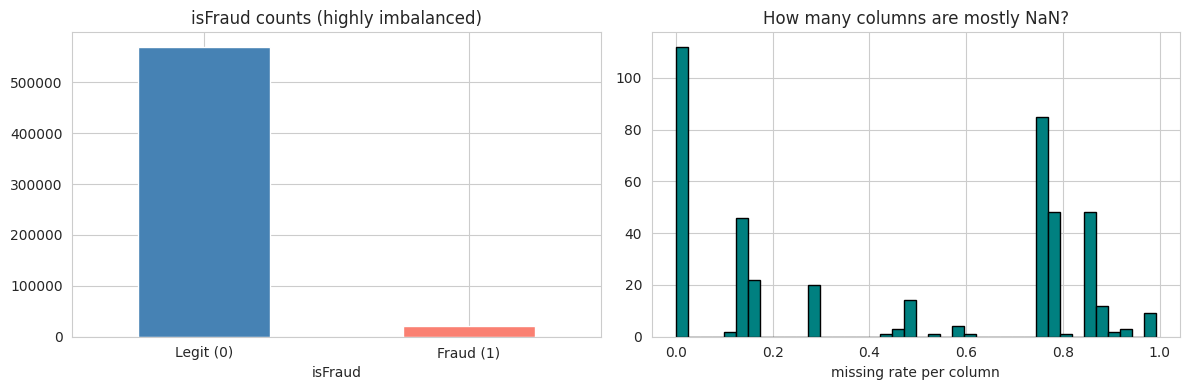


Columns with >50% missing values: 214  / 434
Columns with >90% missing values: 12


In [61]:
# Quick sanity check on class balance and missing rate.
print("Class distribution:")
print(train['isFraud'].value_counts(normalize=True).rename('pct'))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
train['isFraud'].value_counts().plot(kind='bar', ax=ax[0], color=['steelblue','salmon'])
ax[0].set_title('isFraud counts (highly imbalanced)')
ax[0].set_xticklabels(['Legit (0)','Fraud (1)'], rotation=0)

miss = train.isnull().mean().sort_values(ascending=False)
ax[1].hist(miss.values, bins=40, color='teal', edgecolor='black')
ax[1].set_xlabel('missing rate per column')
ax[1].set_title('How many columns are mostly NaN?')
plt.tight_layout(); plt.show()

print(f"\nColumns with >50% missing values: {(miss > 0.5).sum()}  / {train.shape[1]}")
print(f"Columns with >90% missing values: {(miss > 0.9).sum()}")


1. Cleaning

In [62]:
TARGET = "isFraud"
ID_COL = "TransactionID"

def analyse_missing(df, name):
    miss = df.isnull().mean().sort_values(ascending=False)
    almost_empty = miss[miss > 0.95].index.tolist()
    constant     = [c for c in df.columns
                    if df[c].nunique(dropna=False) <= 1]
    print(f"[{name}]  >95% NaN: {len(almost_empty)}   constant: {len(constant)}")
    return sorted(set(almost_empty + constant))

drop_train = analyse_missing(train, "train")
drop_test  = analyse_missing(test,  "test")
DROP_COLS = sorted(set(drop_train) | set(drop_test))
DROP_COLS = [c for c in DROP_COLS if c not in (TARGET, ID_COL)]

print(f"\nWill drop {len(DROP_COLS)} useless columns:")
print(DROP_COLS[:25], "...")

train.drop(columns=DROP_COLS, inplace=True, errors='ignore')
test.drop(columns=DROP_COLS,  inplace=True, errors='ignore')

print(f"\nAfter cleaning - train: {train.shape}, test: {test.shape}")
gc.collect()


[train]  >95% NaN: 9   constant: 0
[test]  >95% NaN: 9   constant: 1

Will drop 10 useless columns:
['V107', 'id_07', 'id_08', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27'] ...

After cleaning - train: (590540, 424), test: (506691, 423)


7728

2. Feature Engineering

In [64]:
EMAIL_HIGH_RISK = {'protonmail.com','mail.com','outlook.es','aim.com',
                   'anonymous.com'}

class FeatureEngineer(BaseEstimator, TransformerMixin):
    """All the engineered features (time, email, amount, aggregations)."""
    def __init__(self):
        self.card1_amt_mean_ = None
        self.card1_amt_std_  = None
        self.freq_maps_      = {}

    def fit(self, X, y=None):
        # Aggregations learned only on TRAIN
        if 'card1' in X.columns and 'TransactionAmt' in X.columns:
            g = X.groupby('card1')['TransactionAmt']
            self.card1_amt_mean_ = g.mean()
            self.card1_amt_std_  = g.std().fillna(0)
        for col in ['card1','card2','card3','card5','addr1','P_emaildomain',
                    'R_emaildomain']:
            if col in X.columns:
                self.freq_maps_[col] = X[col].value_counts(dropna=False)
        return self

    def transform(self, X):
        X = X.copy()
        # ---- time decomposition ----
        if 'TransactionDT' in X.columns:
            X['TX_hour']   = (X['TransactionDT'] // 3600) % 24
            X['TX_day']    = (X['TransactionDT'] // 86400)
            X['TX_dow']    = (X['TX_day'] % 7).astype('int8')
        # ---- amount features ----
        if 'TransactionAmt' in X.columns:
            X['TX_amt_log']     = np.log1p(X['TransactionAmt'])
            X['TX_amt_decimal'] = ((X['TransactionAmt'] -
                                    np.floor(X['TransactionAmt'])) * 1000).astype('int32')
        # ---- email features ----
        for col in ['P_emaildomain','R_emaildomain']:
            if col in X.columns:
                base = X[col].fillna('NA').astype(str)
                X[col + '_base'] = base.str.split('.').str[0]
                X[col + '_suf']  = base.str.split('.').str[-1]
                X[col + '_risk'] = base.isin(EMAIL_HIGH_RISK).astype('int8')
        # ---- card1 aggregations ----
        if self.card1_amt_mean_ is not None and 'card1' in X.columns:
            X['card1_amt_mean'] = X['card1'].map(self.card1_amt_mean_)
            X['card1_amt_std']  = X['card1'].map(self.card1_amt_std_)
            X['card1_amt_diff'] = X['TransactionAmt'] - X['card1_amt_mean']
        # ---- frequency encoding ----
        for col, fmap in self.freq_maps_.items():
            X[col + '_freq'] = X[col].map(fmap).fillna(0).astype('float32')
        return X


class CategoricalEncoder(BaseEstimator, TransformerMixin):
    """Label-encode every object column the same way for train+test.
    Unknown test categories -> -1 (sentinel)."""
    def __init__(self):
        self.maps_ = {}

    def fit(self, X, y=None):
        for c in X.columns:
            if X[c].dtype == 'object' or X[c].dtype.name == 'category':
                vals = X[c].astype(str).fillna('NA').unique()
                self.maps_[c] = {v: i for i, v in enumerate(vals)}
        return self

    def transform(self, X):
        X = X.copy()
        for c, m in self.maps_.items():
            if c in X.columns:
                X[c] = X[c].astype(str).fillna('NA').map(m).fillna(-1).astype('int32')
        return X


class Imputer(BaseEstimator, TransformerMixin):
    """Median imputation for numeric, -1 for categorical/encoded.
    Also clips +-inf to NaN first so downstream models never see a non-finite value."""
    def __init__(self):
        self.medians_ = None

    def fit(self, X, y=None):
        Xc = X.replace([np.inf, -np.inf], np.nan)
        self.medians_ = Xc.median(numeric_only=True)
        return self

    def transform(self, X):
        X = X.copy()
        # Inf -> NaN first (e.g. card1_amt_diff after float32 downcast)
        X = X.replace([np.inf, -np.inf], np.nan)
        for c in X.columns:
            if X[c].isnull().any():
                X[c] = X[c].fillna(self.medians_.get(c, -1))
        # any remaining NaN (e.g. all-NaN col, object col) -> -1
        return X.fillna(-1)


In [65]:
# Build raw matrices we will pass through the FE pipeline
y          = train[TARGET].values
X_train_raw = train.drop(columns=[TARGET, ID_COL])
X_test_raw  = test.drop(columns=[ID_COL])
print(f"Raw shapes: train {X_train_raw.shape}, test {X_test_raw.shape}")

fe_pipeline = Pipeline([
    ('feat',    FeatureEngineer()),
    ('catenc',  CategoricalEncoder()),
    ('impute',  Imputer()),
])

fe_pipeline.fit(X_train_raw, y)
X_train_fe = fe_pipeline.transform(X_train_raw)
X_test_fe  = fe_pipeline.transform(X_test_raw)
print(f"After FE  : train {X_train_fe.shape}, test {X_test_fe.shape}")

# Hard sanity: nothing non-finite reaches feature selection / models.
# (mutual_info_classif and VarianceThreshold both call check_array with
#  force_all_finite=True and will raise ValueError otherwise.)
def assert_finite(df, name):
    nans = int(df.isnull().sum().sum())
    infs = int(np.isinf(df.select_dtypes(include=[np.number]).values).sum())
    print(f"  [{name}] NaNs={nans}, Infs={infs}")
    if nans or infs:
        # belt-and-braces: replace and continue
        df.replace([np.inf, -np.inf], 0, inplace=True)
        df.fillna(0, inplace=True)
        print(f"  [{name}] -> cleaned to all-finite")
    return df

X_train_fe = assert_finite(X_train_fe, 'train_fe')
X_test_fe  = assert_finite(X_test_fe,  'test_fe')


Raw shapes: train (590540, 422), test (506691, 422)
After FE  : train (590540, 443), test (506691, 443)
  [train_fe] NaNs=0, Infs=0
  [test_fe] NaNs=0, Infs=0


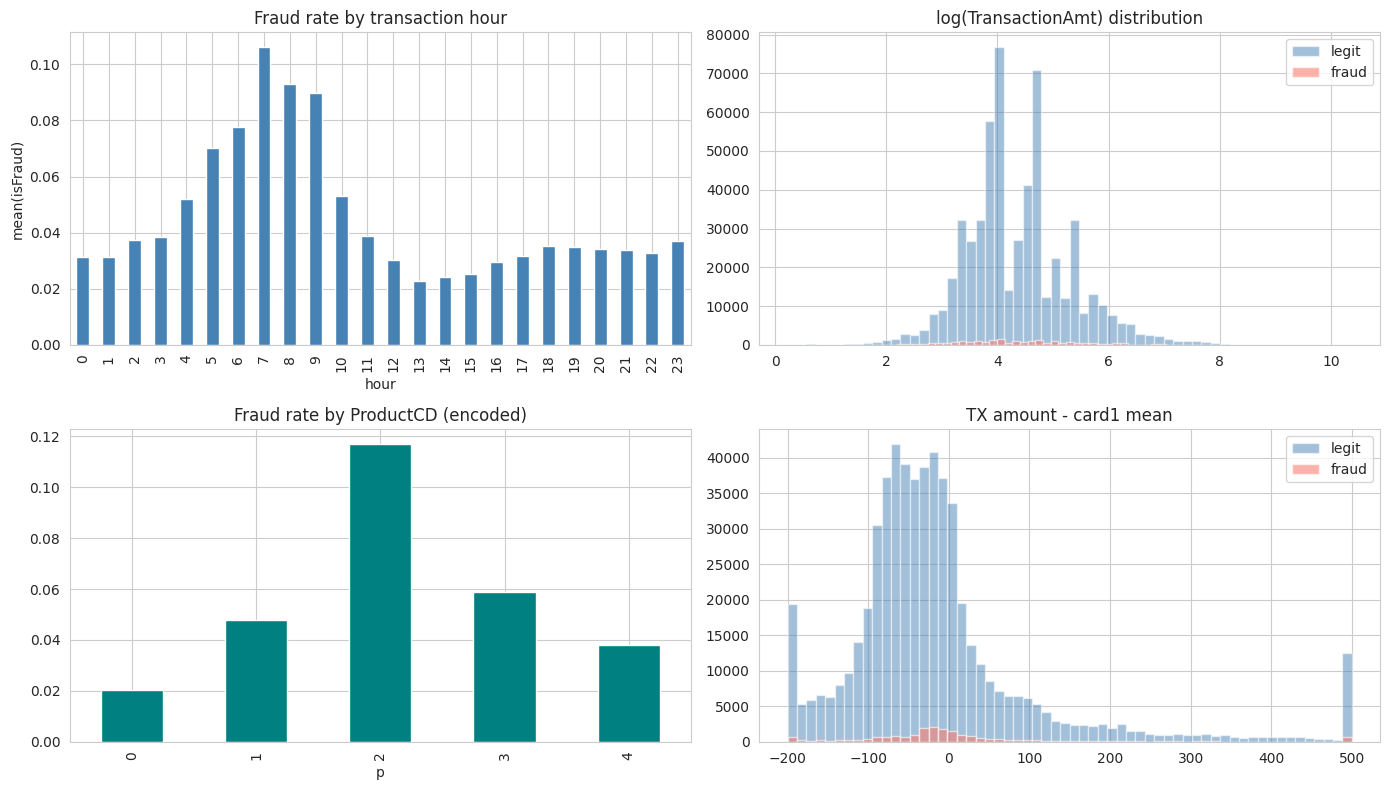

In [67]:
# Visualise a few engineered features vs target
fig, ax = plt.subplots(2, 2, figsize=(14, 8))

# fraud rate by hour
hr = pd.DataFrame({'hour': X_train_fe['TX_hour'], 'fraud': y})
hr.groupby('hour')['fraud'].mean().plot(kind='bar', ax=ax[0,0], color='steelblue')
ax[0,0].set_title('Fraud rate by transaction hour')
ax[0,0].set_ylabel('mean(isFraud)')

# log amount distribution
ax[0,1].hist(X_train_fe.loc[y==0,'TX_amt_log'], bins=60, alpha=.5, label='legit', color='steelblue')
ax[0,1].hist(X_train_fe.loc[y==1,'TX_amt_log'], bins=60, alpha=.6, label='fraud', color='salmon')
ax[0,1].legend(); ax[0,1].set_title('log(TransactionAmt) distribution')

# fraud rate by ProductCD if encoded
if 'ProductCD' in X_train_fe.columns:
    pcd = pd.DataFrame({'p': X_train_fe['ProductCD'], 'fraud': y})
    pcd.groupby('p')['fraud'].mean().plot(kind='bar', ax=ax[1,0], color='teal')
    ax[1,0].set_title('Fraud rate by ProductCD (encoded)')

# card1_amt_diff for fraud vs legit
if 'card1_amt_diff' in X_train_fe.columns:
    ax[1,1].hist(X_train_fe.loc[y==0,'card1_amt_diff'].clip(-200,500), bins=60,
                 alpha=.5, label='legit', color='steelblue')
    ax[1,1].hist(X_train_fe.loc[y==1,'card1_amt_diff'].clip(-200,500), bins=60,
                 alpha=.6, label='fraud', color='salmon')
    ax[1,1].legend(); ax[1,1].set_title('TX amount - card1 mean')

plt.tight_layout(); plt.show()



3. Feature Selection


VarianceThreshold:  kept 419 / 443 columns
Correlation filter (>0.95): dropped 111,  kept 308


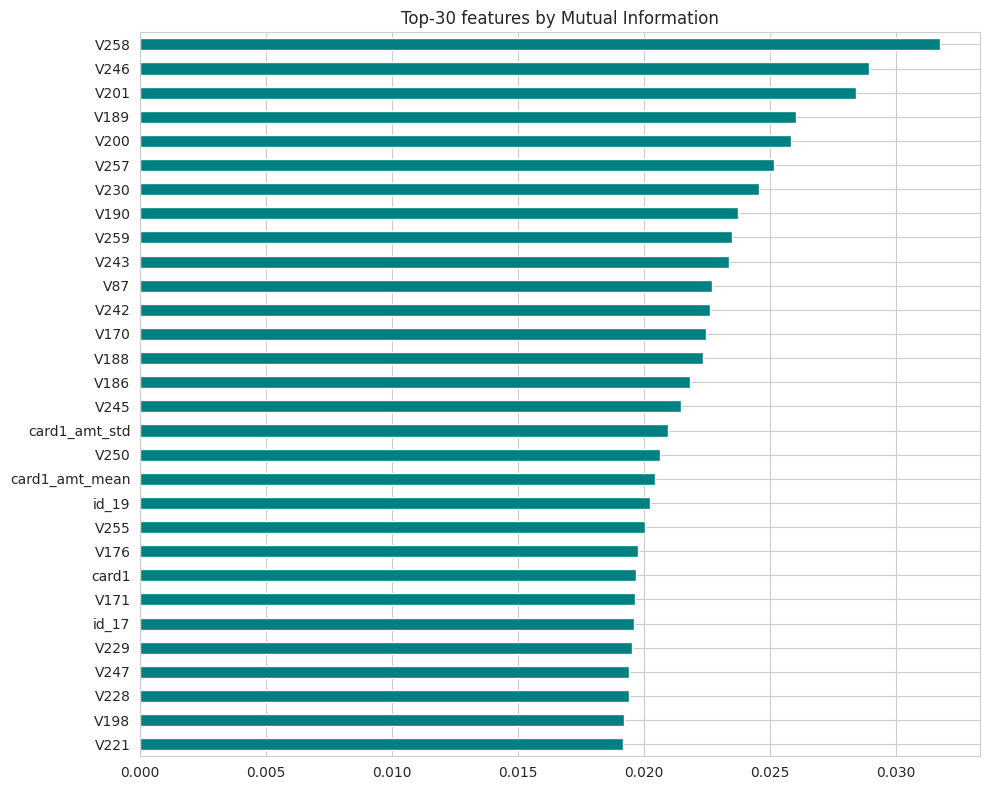


MI top-60 kept.
  all_after_VT         -> 419 features
  corr_filter_0.95     -> 308 features
  MI_top60             -> 60 features


In [68]:
# 3.1 Variance threshold (drop near-constant)
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train_fe)
keep_vt = X_train_fe.columns[vt.get_support()]
print(f"VarianceThreshold:  kept {len(keep_vt)} / {X_train_fe.shape[1]} columns")

# 3.2 Correlation filter
def corr_filter(df, thr=0.95):
    cm = df.corr().abs()
    upper = cm.where(np.triu(np.ones(cm.shape), 1).astype(bool))
    drop = [c for c in upper.columns if (upper[c] > thr).any()]
    return drop
drop_corr = corr_filter(X_train_fe[keep_vt], thr=0.95)
keep_corr = [c for c in keep_vt if c not in drop_corr]
print(f"Correlation filter (>0.95): dropped {len(drop_corr)},  kept {len(keep_corr)}")

# 3.3 Mutual information (sample for speed)
sample_idx = np.random.RandomState(SEED).choice(len(X_train_fe),
                                                size=min(50000, len(X_train_fe)),
                                                replace=False)
mi = mutual_info_classif(X_train_fe.iloc[sample_idx][keep_corr],
                         y[sample_idx], random_state=SEED)
mi_series = pd.Series(mi, index=keep_corr).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
mi_series.head(30).plot(kind='barh', ax=ax, color='teal')
ax.invert_yaxis(); ax.set_title('Top-30 features by Mutual Information')
plt.tight_layout(); plt.show()

TOPK = 60
keep_mi = mi_series.head(TOPK).index.tolist()
print(f"\nMI top-{TOPK} kept.")

FEATURE_SETS = {
    'all_after_VT'     : list(keep_vt),
    'corr_filter_0.95' : keep_corr,
    f'MI_top{TOPK}'    : keep_mi,
}
for name, cols in FEATURE_SETS.items():
    print(f"  {name:20s} -> {len(cols)} features")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

  all_after_VT         |  419 feats | AUC = 0.85833 (+/- 0.00386)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

  corr_filter_0.95     |  308 feats | AUC = 0.85639 (+/- 0.00307)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

  MI_top60             |   60 feats | AUC = 0.78648 (+/- 0.00232)

Best FS = all_after_VT  (419 features)


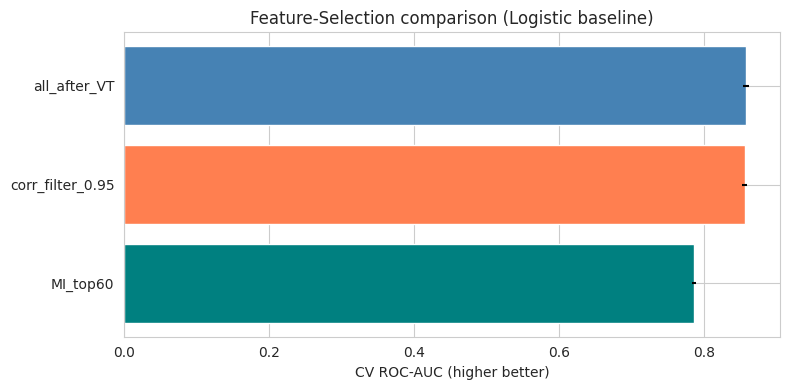

In [70]:
# Compare each feature set with a quick logistic regression CV
from sklearn.linear_model import LogisticRegression as _Quick
quick = _Quick(max_iter=200, n_jobs=-1, solver='lbfgs')
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

fs_results = []
for name, cols in FEATURE_SETS.items():
    Xs = X_train_fe[cols].values
    Xs = StandardScaler(with_mean=False).fit_transform(Xs)
    aucs = cross_val_score(quick, Xs, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    fs_results.append({'method': name, 'n_feat': len(cols),
                       'mean_auc': aucs.mean(), 'std_auc': aucs.std()})
    print(f"  {name:20s} | {len(cols):4d} feats | AUC = {aucs.mean():.5f} (+/- {aucs.std():.5f})")

fs_df = pd.DataFrame(fs_results).sort_values('mean_auc', ascending=False)
best_fs_name = fs_df.iloc[0]['method']
SELECTED_FEATURES = FEATURE_SETS[best_fs_name]
print(f"\nBest FS = {best_fs_name}  ({len(SELECTED_FEATURES)} features)")

fig, ax = plt.subplots(figsize=(8,4))
ax.barh(fs_df['method'], fs_df['mean_auc'], xerr=fs_df['std_auc'],
        color=['steelblue','coral','teal'])
ax.set_xlabel('CV ROC-AUC (higher better)'); ax.invert_yaxis()
ax.set_title('Feature-Selection comparison (Logistic baseline)')
plt.tight_layout(); plt.show()



4Training


In [77]:
def fit_eval(model, X_tr, y_tr, X_val, y_val, cv=None):
    """Train + return metrics dict (no MLflow side-effects)."""
    model.fit(X_tr, y_tr)
    if hasattr(model, "predict_proba"):
        p_tr  = model.predict_proba(X_tr)[:, 1]
        p_val = model.predict_proba(X_val)[:, 1]
    else:
        p_tr  = model.decision_function(X_tr)
        p_val = model.decision_function(X_val)
    pr_tr  = (p_tr  > 0.5).astype(int)
    pr_val = (p_val > 0.5).astype(int)
    metrics = {
        'train_auc'   : roc_auc_score(y_tr,  p_tr),
        'val_auc'     : roc_auc_score(y_val, p_val),
        'train_ap'    : average_precision_score(y_tr,  p_tr),
        'val_ap'      : average_precision_score(y_val, p_val),
        'val_f1'      : f1_score(y_val, pr_val, zero_division=0),
        'val_prec'    : precision_score(y_val, pr_val, zero_division=0),
        'val_recall'  : recall_score(y_val, pr_val, zero_division=0),
        'overfit_gap' : roc_auc_score(y_tr, p_tr) - roc_auc_score(y_val, p_val),
    }
    if cv is not None:
        cv_aucs = cross_val_score(model, X_tr, y_tr, cv=cv,
                                  scoring='roc_auc', n_jobs=-1)
        metrics['cv_auc_mean'] = cv_aucs.mean()
        metrics['cv_auc_std']  = cv_aucs.std()
    return metrics

def print_m(tag, m):
    print(f"  [{tag}]")
    for k, v in m.items():
        print(f"    {k:14s} = {v:.5f}")

results_log = []
print(1)

1


In [78]:
from sklearn.linear_model import LogisticRegression

# CV setup + train/val split
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
X_sel = X_train_fe[SELECTED_FEATURES].astype(np.float32).values
X_tr, X_val, y_tr, y_val = train_test_split(X_sel, y, test_size=0.2,
                                            stratify=y, random_state=SEED)
scaler = StandardScaler(with_mean=False)
X_tr_s, X_val_s = scaler.fit_transform(X_tr), scaler.transform(X_val)
print(f"X_tr {X_tr.shape}, X_val {X_val.shape}, fraud rate val = {y_val.mean():.4f}")


X_tr (472432, 419), X_val (118108, 419), fraud rate val = 0.0350


In [79]:
m = LogisticRegression(C=0.01, max_iter=300, n_jobs=-1, solver='lbfgs', class_weight='balanced')
mt = fit_eval(m, X_tr_s, y_tr, X_val_s, y_val)
print_m("C=0.01,  l2 strong", mt)
results_log.append({'name': "LogReg_C=0.01,  l2 strong", 'model': m, **mt})


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  [C=0.01,  l2 strong]
    train_auc      = 0.86847
    val_auc        = 0.86608
    train_ap       = 0.42714
    val_ap         = 0.43119
    val_f1         = 0.23005
    val_prec       = 0.13633
    val_recall     = 0.73603
    overfit_gap    = 0.00240


In [80]:
m = LogisticRegression(C=0.1,  max_iter=300, n_jobs=-1, solver='lbfgs', class_weight='balanced')
mt = fit_eval(m, X_tr_s, y_tr, X_val_s, y_val)
print_m("C=0.1,   l2 medium", mt)
results_log.append({'name': "LogReg_C=0.1,   l2 medium", 'model': m, **mt})


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  [C=0.1,   l2 medium]
    train_auc      = 0.86972
    val_auc        = 0.86676
    train_ap       = 0.42789
    val_ap         = 0.43138
    val_f1         = 0.23136
    val_prec       = 0.13720
    val_recall     = 0.73748
    overfit_gap    = 0.00296


In [81]:
m = LogisticRegression(C=1.0,  max_iter=300, n_jobs=-1, solver='lbfgs', class_weight='balanced')
mt = fit_eval(m, X_tr_s, y_tr, X_val_s, y_val)
print_m("C=1.0,   default", mt)
results_log.append({'name': "LogReg_C=1.0,   default", 'model': m, **mt})


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  [C=1.0,   default]
    train_auc      = 0.86821
    val_auc        = 0.86569
    train_ap       = 0.42561
    val_ap         = 0.42949
    val_f1         = 0.22877
    val_prec       = 0.13547
    val_recall     = 0.73506
    overfit_gap    = 0.00252


In [82]:
m = LogisticRegression(C=10.0, max_iter=300, n_jobs=-1, solver='lbfgs', class_weight='balanced')
mt = fit_eval(m, X_tr_s, y_tr, X_val_s, y_val)
print_m("C=10,    weak l2", mt)
results_log.append({'name': "LogReg_C=10,    weak l2", 'model': m, **mt})


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  [C=10,    weak l2]
    train_auc      = 0.86913
    val_auc        = 0.86658
    train_ap       = 0.42777
    val_ap         = 0.43153
    val_f1         = 0.23106
    val_prec       = 0.13696
    val_recall     = 0.73820
    overfit_gap    = 0.00254


In [83]:
m = LogisticRegression(C=1.0,  max_iter=300, n_jobs=-1, solver='lbfgs')
mt = fit_eval(m, X_tr_s, y_tr, X_val_s, y_val)
print_m("C=1.0,   no weight", mt)
results_log.append({'name': "LogReg_C=1.0,   no weight", 'model': m, **mt})


  [C=1.0,   no weight]
    train_auc      = 0.86202
    val_auc        = 0.85922
    train_ap       = 0.45071
    val_ap         = 0.45281
    val_f1         = 0.38924
    val_prec       = 0.81671
    val_recall     = 0.25550
    overfit_gap    = 0.00279


In [84]:
m = LogisticRegression(C=1.0,  max_iter=300, n_jobs=-1, solver='saga', penalty='l1', class_weight='balanced')
mt = fit_eval(m, X_tr_s, y_tr, X_val_s, y_val)
print_m("C=1.0,   l1 lasso", mt)
results_log.append({'name': "LogReg_C=1.0,   l1 lasso", 'model': m, **mt})


  [C=1.0,   l1 lasso]
    train_auc      = 0.85812
    val_auc        = 0.85750
    train_ap       = 0.40020
    val_ap         = 0.40627
    val_f1         = 0.22072
    val_prec       = 0.12995
    val_recall     = 0.73216
    overfit_gap    = 0.00063


                     name  train_auc  val_auc   val_f1   val_ap  overfit_gap diagnosis
LogReg_C=0.1,   l2 medium   0.869720 0.866756 0.231365 0.431380     0.002964   HEALTHY
  LogReg_C=10,    weak l2   0.869128 0.866583 0.231058 0.431533     0.002545   HEALTHY
LogReg_C=0.01,  l2 strong   0.868473 0.866077 0.230054 0.431186     0.002396   HEALTHY
  LogReg_C=1.0,   default   0.868209 0.865693 0.228774 0.429494     0.002516   HEALTHY
LogReg_C=1.0,   no weight   0.862015 0.859221 0.389237 0.452808     0.002794   HEALTHY
 LogReg_C=1.0,   l1 lasso   0.858122 0.857495 0.220723 0.406274     0.000627   HEALTHY


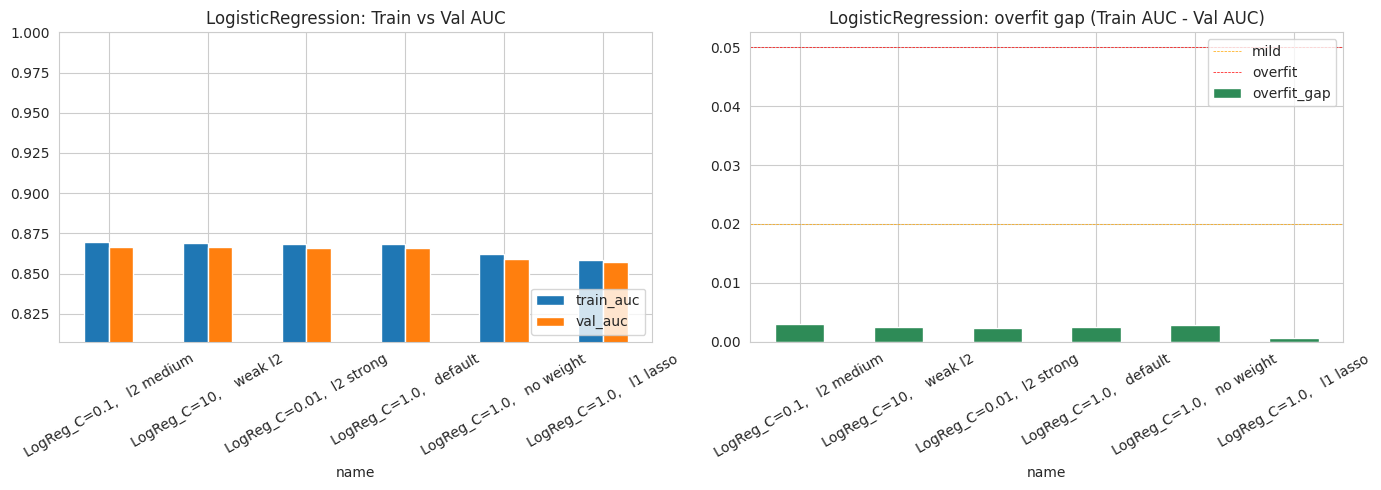

-> picked best_model = LogReg_C=0.1,   l2 medium


In [86]:
df_results = pd.DataFrame([{k:v for k,v in r.items() if k!='model'} for r in results_log])
df_results = df_results.sort_values('val_auc', ascending=False).reset_index(drop=True)

# Diagnose each run: overfit / underfit / healthy.
# Heuristic for fraud detection (AUC):
#   - train AUC < 0.75  -> underfit (model can't learn the task)
#   - overfit_gap > 0.05 -> overfit (memorising train, fails on val)
#   - 0 <= overfit_gap <= 0.02 and val_auc > 0.85 -> healthy
def _diag(row):
    if row['train_auc'] < 0.75:
        return 'UNDERFIT'
    if row['overfit_gap'] > 0.05:
        return 'OVERFIT'
    if row['overfit_gap'] < 0:
        return 'lucky-val'
    if row['val_auc'] >= 0.85 and row['overfit_gap'] <= 0.02:
        return 'HEALTHY'
    return 'mild-overfit' if row['overfit_gap'] > 0.02 else 'ok'
df_results['diagnosis'] = df_results.apply(_diag, axis=1)

_default_cols = ['name','train_auc','val_auc','val_f1','val_ap','overfit_gap','diagnosis']
show_cols = [c for c in _default_cols if c in df_results.columns]
print(df_results[show_cols].to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df_results.set_index('name')[['train_auc','val_auc']].plot(kind='bar', ax=ax[0])
ax[0].set_title('LogisticRegression: Train vs Val AUC')
ax[0].set_ylim(max(0.5, df_results[['train_auc','val_auc']].min().min()-0.05), 1.0)
ax[0].tick_params(axis='x', rotation=30); ax[0].legend(loc='lower right')

colors = ['salmon' if g > 0.05 else ('orange' if g > 0.02 else 'seagreen')
          for g in df_results['overfit_gap']]
df_results.set_index('name')['overfit_gap'].plot(kind='bar', ax=ax[1], color=colors)
ax[1].axhline(0,    color='black', lw=0.5)
ax[1].axhline(0.02, color='orange', ls='--', lw=0.5, label='mild')
ax[1].axhline(0.05, color='red',    ls='--', lw=0.5, label='overfit')
ax[1].set_title('LogisticRegression: overfit gap (Train AUC - Val AUC)')
ax[1].tick_params(axis='x', rotation=30); ax[1].legend(loc='upper right')
plt.tight_layout(); plt.show()

n_over   = int((df_results['diagnosis']=='OVERFIT').sum())
n_under  = int((df_results['diagnosis']=='UNDERFIT').sum())
n_health = int((df_results['diagnosis']=='HEALTHY').sum())
best     = df_results.iloc[0]
worst    = df_results.iloc[-1]


best_model = [r['model'] for r in results_log if r['name']==best['name']][0]
print(f"-> picked best_model = {best['name']}")


Pipeline Construction


In [87]:
import pickle
from sklearn.pipeline import Pipeline

class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, cols): self.cols = cols
    def fit(self, X, y=None): return self
    def transform(self, X): return X[self.cols]

# Build a single pipeline that runs on RAW test data
final_pipeline = Pipeline([
    ('feat',   FeatureEngineer()),
    ('catenc', CategoricalEncoder()),
    ('impute', Imputer()),
    ('select', ColumnSelector(SELECTED_FEATURES)),
    ('model',  best_model),
])

# Refit FE part + best model on the FULL training data (raw)
final_pipeline.fit(X_train_raw, y)
print("Pipeline fitted on full raw training data.")

# Sanity: probabilistic predictions on raw test
test_pred_proba = final_pipeline.predict_proba(X_test_raw)[:, 1]
print(f"Test prediction probabilities sample: {test_pred_proba[:5]}")
print(f"Mean predicted P(fraud) on test set : {test_pred_proba.mean():.4f}")

# Save pipeline locally too (optional)
PIPE_PATH = f"pipeline_{MODEL_TAG}.pkl"
with open(PIPE_PATH, 'wb') as f:
    pickle.dump(final_pipeline, f)
print(f"Pipeline saved to {PIPE_PATH}")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline fitted on full raw training data.
Test prediction probabilities sample: [0.38961419 0.39079958 0.45697266 0.40704652 0.50835496]
Mean predicted P(fraud) on test set : 0.5620
Pipeline saved to pipeline_LogisticRegression.pkl


6. MLflow Logging 



In [91]:
# 6.3  Cleaning summary run
mlflow.set_experiment(MLFLOW_EXPERIMENT)
with mlflow.start_run(run_name=f"{MODEL_TAG}_Cleaning"):
    mlflow.log_param('stage', 'cleaning')
    mlflow.log_param('dropped_columns', len(DROP_COLS))
    mlflow.log_param('train_shape_after', str(train.shape))
    mlflow.log_param('test_shape_after',  str(test.shape))
print("Cleaning run logged.")


🏃 View run LogisticRegression_Cleaning at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/3/runs/0a1134bba9b4429785d09dcc6043c8c3
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/3
Cleaning run logged.


In [90]:
# 6.2  Feature-Selection comparison run
mlflow.set_experiment(MLFLOW_EXPERIMENT)
with mlflow.start_run(run_name=f"{MODEL_TAG}_Feature_Selection"):
    mlflow.log_param('stage', 'feature_selection')
    mlflow.log_param('chosen', best_fs_name if 'best_fs_name' in dir() else 'n/a')
    mlflow.log_param('n_selected', len(SELECTED_FEATURES))
    if 'fs_df' in dir():
        for _, row in fs_df.iterrows():
            mlflow.log_metric(f"AUC_{row['method']}", float(row['mean_auc']))
print("Feature Selection run logged.")


🏃 View run LogisticRegression_Feature_Selection at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/3/runs/459b0adcea0f4a68b5601087de290d79
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/3
Feature Selection run logged.


In [92]:
# 6.3.5  Feature Engineering summary run
mlflow.set_experiment(MLFLOW_EXPERIMENT)
with mlflow.start_run(run_name=f"{MODEL_TAG}_Feature_Engineering"):
    mlflow.log_param('stage', 'feature_engineering')
    mlflow.log_param('n_input_cols',  X_train_raw.shape[1])
    mlflow.log_param('n_output_cols', X_train_fe.shape[1])
    mlflow.log_param('n_added',       X_train_fe.shape[1] - X_train_raw.shape[1])

    # Engineered feature groups (from the FeatureEngineer transformer)
    fe_groups = {
        'time'    : [c for c in X_train_fe.columns if c.startswith('TX_hour') or c.startswith('TX_day') or c.startswith('TX_dow')],
        'amount'  : [c for c in X_train_fe.columns if c.startswith('TX_amt_')],
        'email'   : [c for c in X_train_fe.columns if c.endswith('_base') or c.endswith('_suf') or c.endswith('_risk')],
        'card_agg': [c for c in X_train_fe.columns if c.startswith('card1_amt')],
        'freq'    : [c for c in X_train_fe.columns if c.endswith('_freq')],
    }
    for grp, cols in fe_groups.items():
        mlflow.log_param(f'fe_{grp}_count', len(cols))
        mlflow.log_param(f'fe_{grp}_sample', ', '.join(cols[:5]))
    mlflow.log_param('transformers', 'FeatureEngineer + CategoricalEncoder + Imputer')
print("Feature Engineering run logged.")

🏃 View run LogisticRegression_Feature_Engineering at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/3/runs/410bd9ad47044ce3a7c155274c88e7f8
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/3
Feature Engineering run logged.


In [88]:
# 6.1  Per-hyperparameter runs
mlflow.set_experiment(MLFLOW_EXPERIMENT)

for r in results_log:
    with mlflow.start_run(run_name=r['name']):
        # Params (model + general)
        mlflow.log_param('model_type',        MODEL_TAG)
        mlflow.log_param('n_features',        len(SELECTED_FEATURES))
        mlflow.log_param('feature_selection', best_fs_name if 'best_fs_name' in dir() else 'manual')
        mlflow.log_param('config',            r['name'])
        # Metrics
        for k, v in r.items():
            if k in ('name','model'): continue
            try: mlflow.log_metric(k, float(v))
            except Exception: pass
print("Logged all training runs to MLflow.")


2026/05/04 04:19:19 INFO mlflow.tracking.fluent: Experiment with name 'LogisticRegression_Training' does not exist. Creating a new experiment.


🏃 View run LogReg_C=0.01,  l2 strong at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/3/runs/1e7b853dbdba4ed89ef8e5146132aca2
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/3
🏃 View run LogReg_C=0.1,   l2 medium at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/3/runs/9b55b83ea9624a619dd2a0d10549d3c6
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/3
🏃 View run LogReg_C=1.0,   default at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/3/runs/fa2efaf494174ae48c3e9fb5b3031d4d
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/3
🏃 View run LogReg_C=10,    weak l2 at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/3/runs/e66fc078350d481ab2659ec53bcca192
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/3
🏃 View run LogReg_C=1.0,   no weight at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/3/runs/d7a61370f3454e0f92f6a37f5ea8d07c

In [93]:
# 6.4  Cross-validation run for the BEST hyperparameter set
mlflow.set_experiment(MLFLOW_EXPERIMENT)
print("Re-running 5-fold CV for the BEST config (this can take a few min)...")
cv5_aucs = cross_val_score(best_model, X_train_fe[SELECTED_FEATURES].values, y,
                           cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                           scoring='roc_auc', n_jobs=-1)
print(f"CV AUC mean = {cv5_aucs.mean():.5f} +/- {cv5_aucs.std():.5f}")

with mlflow.start_run(run_name=f"{MODEL_TAG}_CrossValidation"):
    mlflow.log_param('stage', 'cross_validation')
    mlflow.log_param('cv_folds', 5)
    mlflow.log_param('best_config', best['name'])
    mlflow.log_metric('cv_auc_mean', float(cv5_aucs.mean()))
    mlflow.log_metric('cv_auc_std',  float(cv5_aucs.std()))
    for i, a in enumerate(cv5_aucs):
        mlflow.log_metric(f'cv_auc_fold{i+1}', float(a))
print("Cross-validation run logged.")


Re-running 5-fold CV for the BEST config (this can take a few min)...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

CV AUC mean = 0.73443 +/- 0.00376
🏃 View run LogisticRegression_CrossValidation at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/3/runs/f989178190ee40f79f1e86f4a018e882
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/3
Cross-validation run logged.


In [94]:
# 6.5  FINAL run -- log the trained Pipeline as MLflow artifact
mlflow.set_experiment(MLFLOW_EXPERIMENT)
with mlflow.start_run(run_name=f"{MODEL_TAG}_Final_Pipeline"):
    mlflow.log_param('model_type',        MODEL_TAG)
    mlflow.log_param('best_config',       best['name'])
    mlflow.log_param('n_features',        len(SELECTED_FEATURES))
    mlflow.log_param('feature_selection', best_fs_name if 'best_fs_name' in dir() else 'manual')

    mlflow.log_metric('best_val_auc',     float(best['val_auc']))
    mlflow.log_metric('best_train_auc',   float(best['train_auc']))
    mlflow.log_metric('best_overfit_gap', float(best['overfit_gap']))
    if 'cv5_aucs' in dir():
        mlflow.log_metric('cv_auc_mean', float(cv5_aucs.mean()))

    # Log entire pipeline (preprocessing + model) as an MLflow sklearn model
    # so model_inference can load it from the registry directly.
    mlflow.sklearn.log_model(
        sk_model=final_pipeline,
        artifact_path='model',
        registered_model_name=f'IEEE_Fraud_{MODEL_TAG}',
    )

print(f"Final pipeline logged & registered as 'IEEE_Fraud_{MODEL_TAG}'.")
print("In model_inference.ipynb you can now load it via:")
print(f"    mlflow.sklearn.load_model('models:/IEEE_Fraud_{MODEL_TAG}/latest')")


2026/05/04 04:27:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 04:27:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'IEEE_Fraud_LogisticRegression'.
2026/05/04 04:27:20 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: IEEE_Fraud_LogisticRegression, version 1
Created version '1' of model 'IEEE_Fraud_LogisticRegression'.


🏃 View run LogisticRegression_Final_Pipeline at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/3/runs/4b868ae14589449bb5bf688f2d0aae6e
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/3
Final pipeline logged & registered as 'IEEE_Fraud_LogisticRegression'.
In model_inference.ipynb you can now load it via:
    mlflow.sklearn.load_model('models:/IEEE_Fraud_LogisticRegression/latest')
